In [10]:
import pandas as pd
from bsse_calculator.plotting_helpers import (
    make_bsse_contour_plots,
    fit_gaussian,
    make_contour_plots_of_fitted_gaussian,
    predicted_v_actual_plot,
    make_error_contour_plots,
)

In [11]:
bsse_data_nwchem_kcal = pd.read_csv("BSSE_by_Ne_Ne_distance_nwchem.csv")

In [12]:
for column in bsse_data_nwchem_kcal.columns:
    if "energy" in column:
        bsse_data_nwchem_kcal[column] = bsse_data_nwchem_kcal[column].apply(
            lambda x: float(x.strip("()").split(",")[0])
        )
        bsse_data_nwchem_kcal[column] = bsse_data_nwchem_kcal[column].apply(
            lambda x: x * 627.5096
        )

In [13]:
total_energies = pd.DataFrame()

In [14]:
for column in bsse_data_nwchem_kcal.columns:
    if "Total_energy" in column:
        total_energies[column.replace("Total_energy_", "")] = bsse_data_nwchem_kcal[
            column
        ]

total_energies["x"] = bsse_data_nwchem_kcal["x"]
total_energies["y"] = bsse_data_nwchem_kcal["y"]
total_energies["z"] = bsse_data_nwchem_kcal["z"]

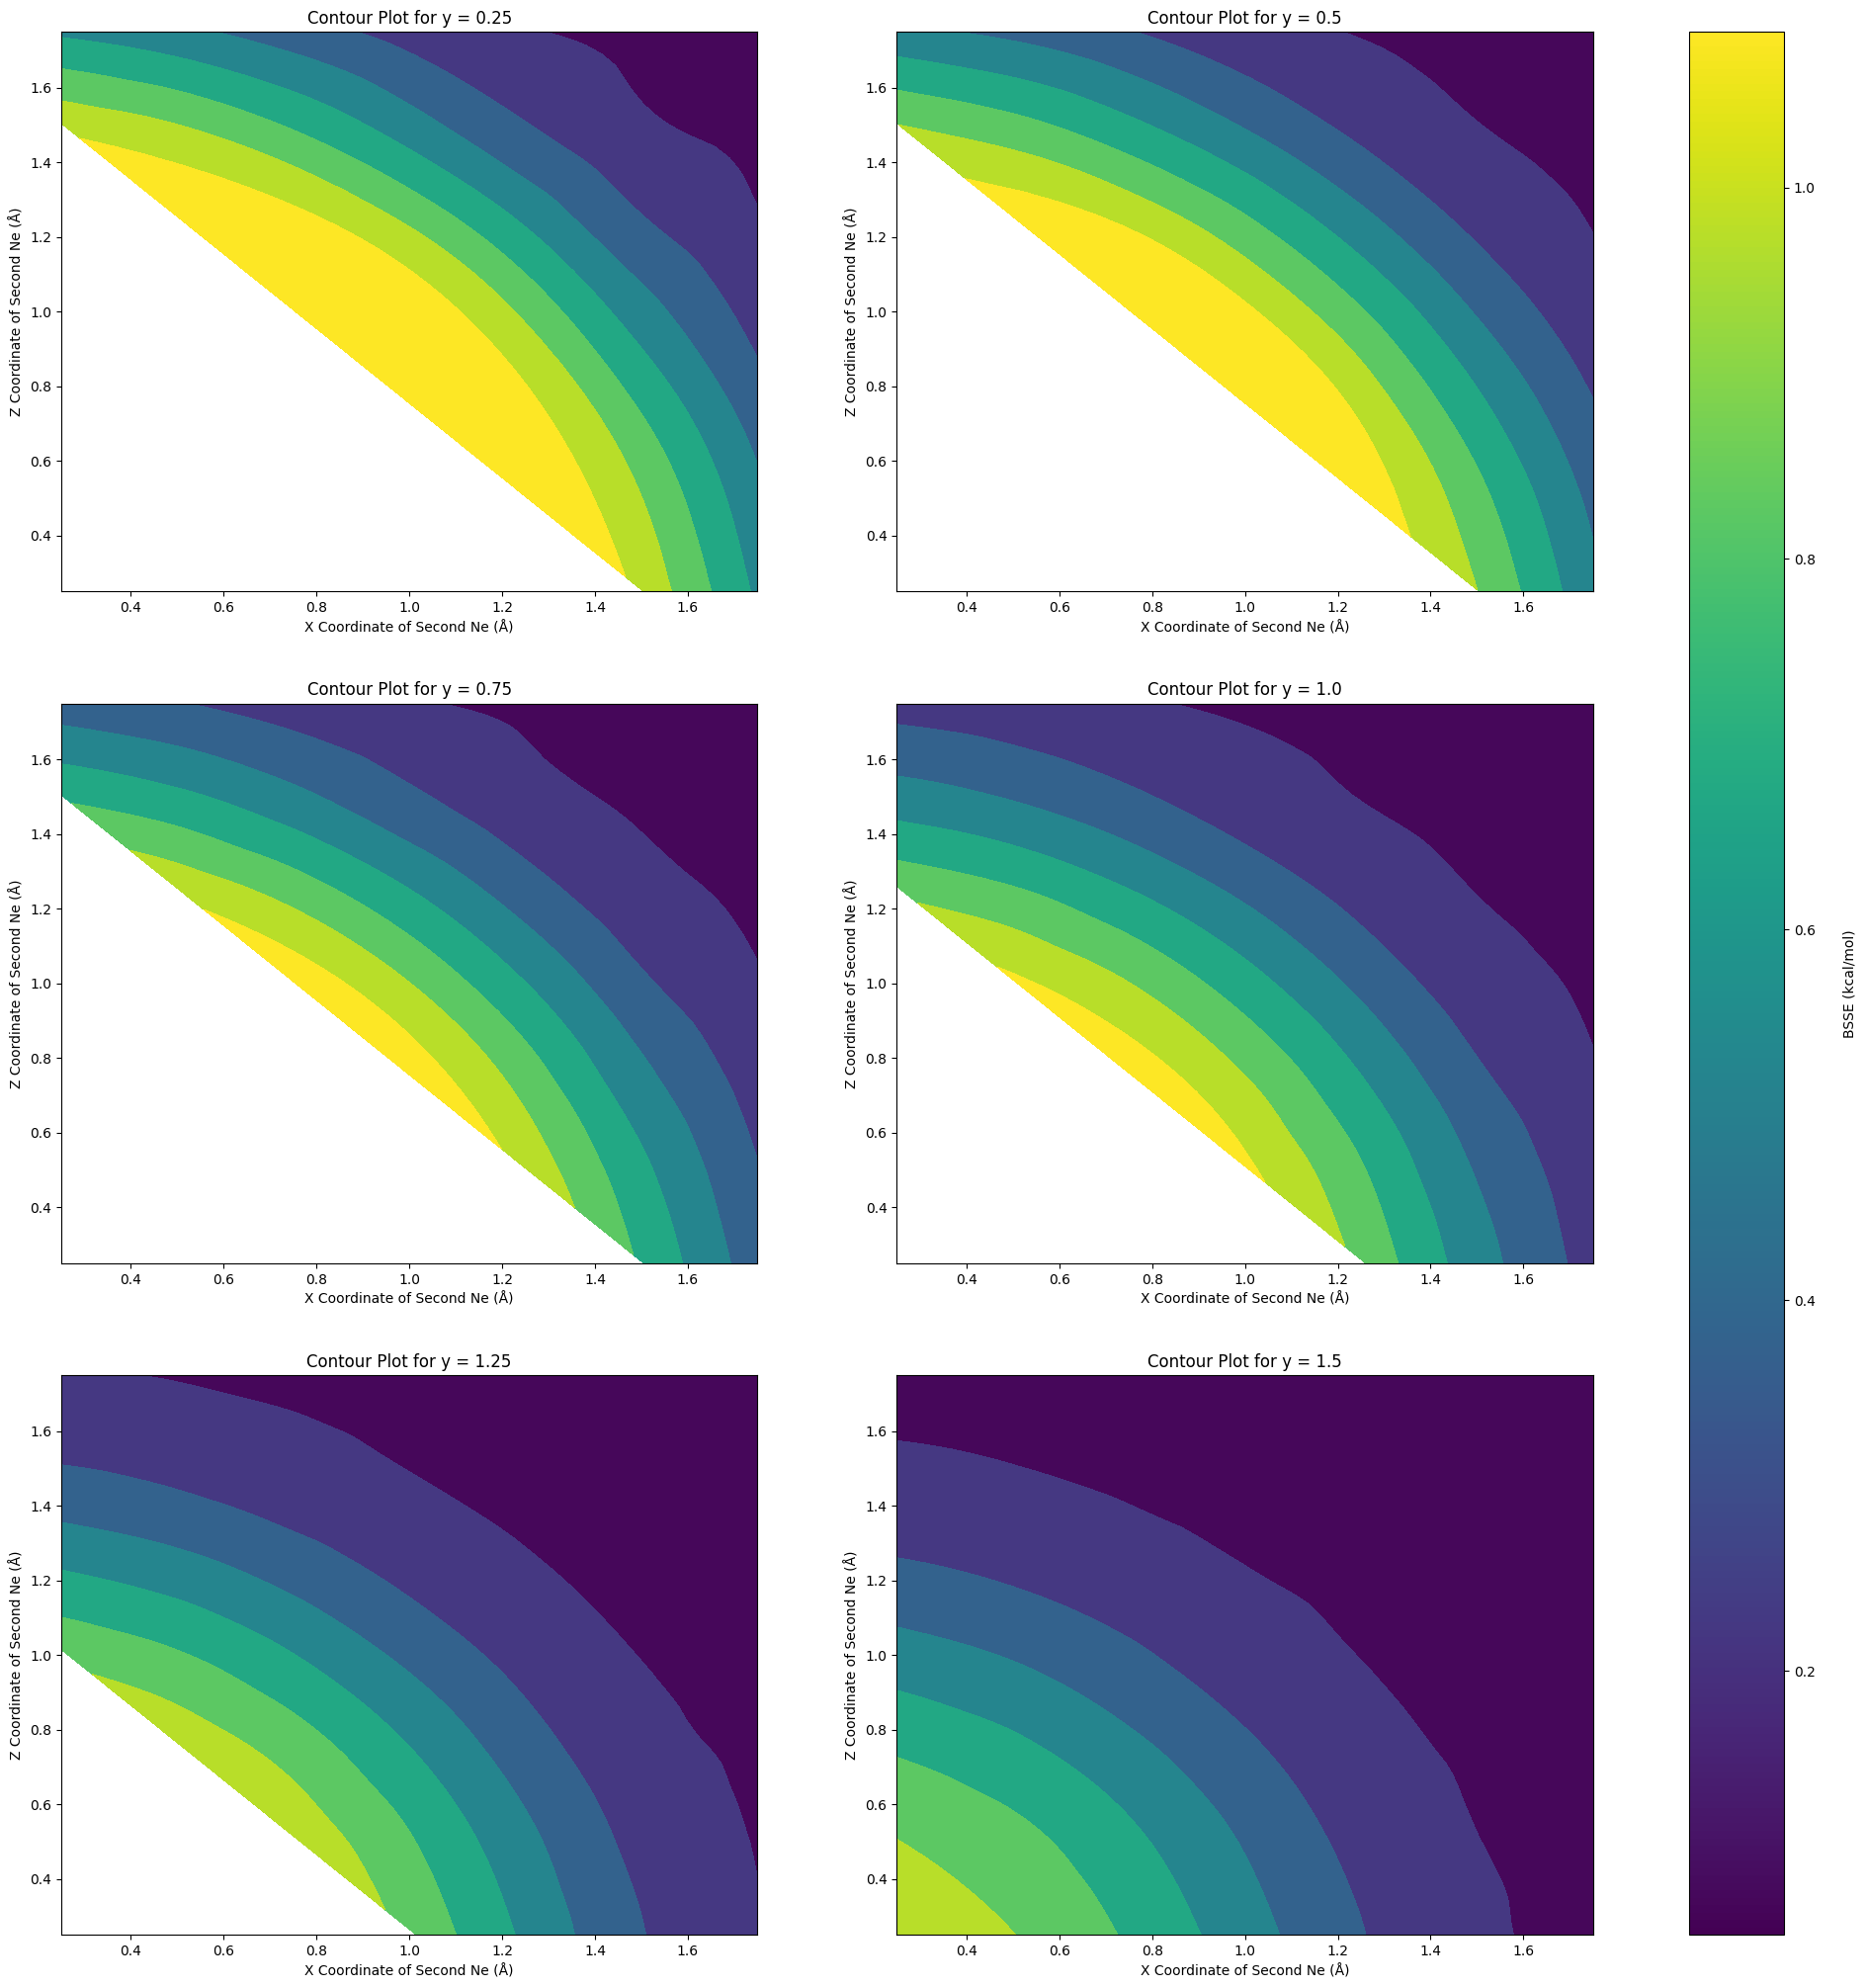

In [15]:
make_bsse_contour_plots(total_energies, "Ne")

In [16]:
total_energies["distance"] = np.sqrt(
    total_energies["x"] ** 2 + total_energies["y"] ** 2 + total_energies["z"] ** 2
)

In [17]:
total_energies

,Delta_E_AB_AB,BSSE_A,BSSE_B,x,y,z,distance
0,75.742250,1.011165,1.011156,0.25,0.25,1.50,1.541104
1,24.375013,0.573916,0.573914,0.25,0.25,1.75,1.785357
2,57.468098,0.903610,0.903612,0.25,0.50,1.50,1.600781
3,19.133891,0.489365,0.489376,0.25,0.50,1.75,1.837117
4,37.024673,0.731124,0.731129,0.25,0.75,1.50,1.695582
...,...,...,...,...,...,...,...
263,0.479599,0.103892,0.103912,1.75,1.75,0.75,2.586020
264,0.300344,0.093129,0.093131,1.75,1.75,1.00,2.669270
265,0.158117,0.079857,0.079854,1.75,1.75,1.25,2.772634
266,0.062010,0.067276,0.067279,1.75,1.75,1.50,2.893959


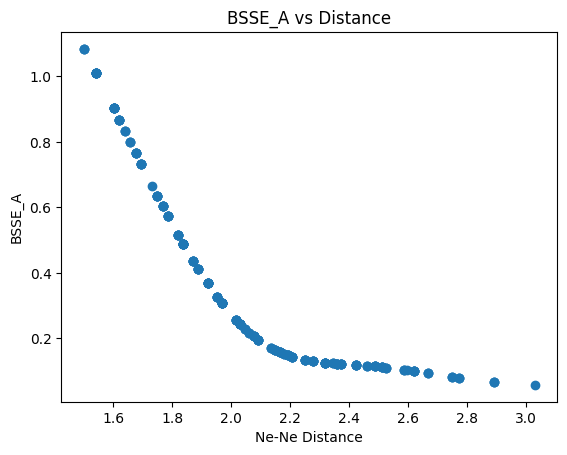

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(total_energies["distance"], total_energies["BSSE_A"])
ax.set_xlabel("Ne-Ne Distance")
ax.set_ylabel("BSSE_A")
ax.set_title("BSSE_A vs Distance")
plt.show()

In [19]:
bsse_data_nwchem_kcal.columns

Index(['Total_energy_Delta_E_AB_AB', 'Total_energy_BSSE_A',
       'Total_energy_BSSE_B', 'MP2_correlation_energy_Delta_E_AB_AB',
       'MP2_correlation_energy_BSSE_A', 'MP2_correlation_energy_BSSE_B',
       '(T)_correlation_energy_Delta_E_AB_AB', '(T)_correlation_energy_BSSE_A',
       '(T)_correlation_energy_BSSE_B',
       'CCSD_3correlation_energy_Delta_E_AB_AB',
       'CCSD_3correlation_energy_BSSE_A', 'CCSD_3correlation_energy_BSSE_B',
       'SCF_energy_Delta_E_AB_AB', 'SCF_energy_BSSE_A', 'SCF_energy_BSSE_B',
       'x', 'y', 'z'],
      dtype='object')

In [20]:
bsse_data_nwchem_kcal["distance"] = np.sqrt(
    bsse_data_nwchem_kcal["x"] ** 2
    + bsse_data_nwchem_kcal["y"] ** 2
    + bsse_data_nwchem_kcal["z"] ** 2
)

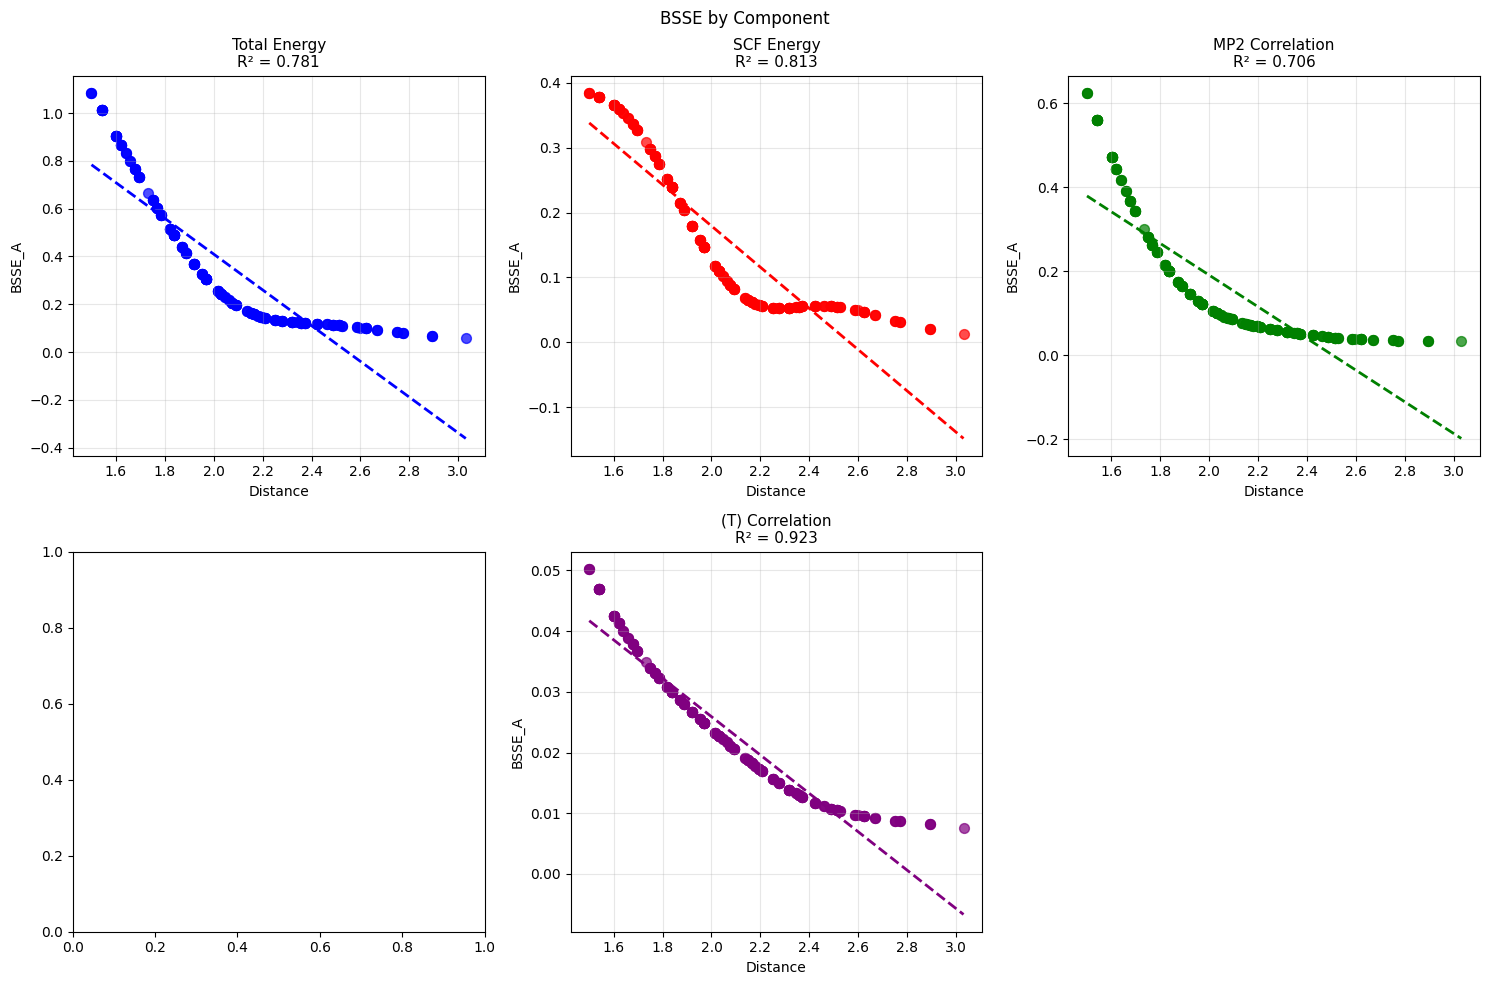

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Read the CSV file
df = bsse_data_nwchem_kcal

# Define the energy types and their corresponding BSSE_A columns
energy_types = {
    "Total Energy": "Total_energy_BSSE_A",
    "SCF Energy": "SCF_energy_BSSE_A",
    "MP2 Correlation": "MP2_correlation_energy_BSSE_A",
    "CCSD Correlation": "CCSD corr.energy_BSSE_A",
    "(T) Correlation": "(T)_correlation_energy_BSSE_A",
}

# Create separate subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten for easier indexing

# Define colors for each energy type
colors = ["blue", "red", "green", "orange", "purple"]

# Plot each energy type in separate subplot
for i, (label, column) in enumerate(energy_types.items()):
    if column in df.columns and i < len(axes):
        ax = axes[i]

        # Remove any NaN values
        mask = ~(df["distance"].isna() | df[column].isna())
        x = df.loc[mask, "distance"].values
        y = df.loc[mask, column].values

        if len(x) > 0:  # Only plot if we have data
            # Plot scatter points
            ax.scatter(x, y, color=colors[i], alpha=0.7, s=50)

            # Fit linear regression
            if len(x) > 1:  # Need at least 2 points for linear fit
                X = x.reshape(-1, 1)
                reg = LinearRegression().fit(X, y)

                # Generate fitted line
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = reg.predict(x_fit.reshape(-1, 1))

                # Calculate R-squared
                y_pred = reg.predict(X)
                r2 = r2_score(y, y_pred)

                # Plot fitted line
                ax.plot(x_fit, y_fit, color=colors[i], linestyle="--", linewidth=2)

                # Customize individual subplot
                ax.set_xlabel("Distance", fontsize=10)
                ax.set_ylabel("BSSE_A", fontsize=10)
                ax.set_title(f"{label}\nR² = {r2:.3f}", fontsize=11)
                ax.grid(True, alpha=0.3)

# Hide the last subplot if we have fewer than 6 energy types
if len(energy_types) < len(axes):
    axes[-1].axis("off")

# Adjust layout
plt.tight_layout()
fig.suptitle("BSSE by Component")
plt.tight_layout()
# Show the plot
plt.show()

# Optional: Save the plot
# plt.savefig('energy_delta_separate_plots.png', dpi=300, bbox_inches='tight')

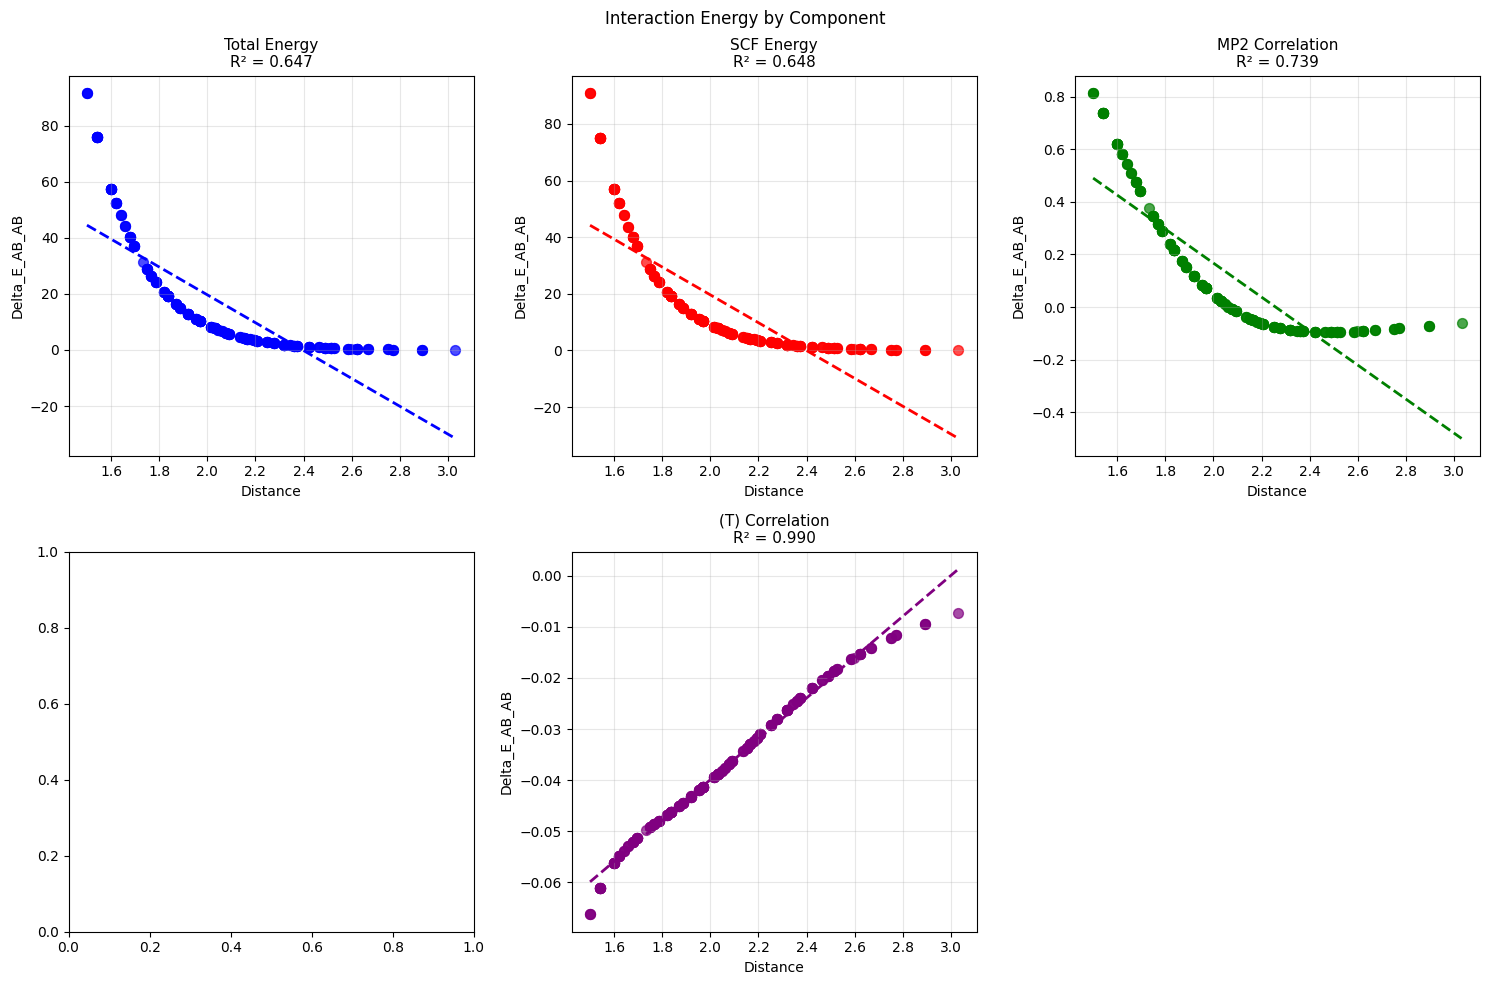

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Read the CSV file
df = bsse_data_nwchem_kcal

# Define the energy types and their corresponding Delta_E_AB_AB columns
energy_types = {
    "Total Energy": "Total_energy_Delta_E_AB_AB",
    "SCF Energy": "SCF_energy_Delta_E_AB_AB",
    "MP2 Correlation": "MP2_correlation_energy_Delta_E_AB_AB",
    "CCSD Correlation": "CCSD corr.energy_Delta_E_AB_AB",
    "(T) Correlation": "(T)_correlation_energy_Delta_E_AB_AB",
}

# Create separate subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten for easier indexing

# Define colors for each energy type
colors = ["blue", "red", "green", "orange", "purple"]

# Plot each energy type in separate subplot
for i, (label, column) in enumerate(energy_types.items()):
    if column in df.columns and i < len(axes):
        ax = axes[i]

        # Remove any NaN values
        mask = ~(df["distance"].isna() | df[column].isna())
        x = df.loc[mask, "distance"].values
        y = df.loc[mask, column].values

        if len(x) > 0:  # Only plot if we have data
            # Plot scatter points
            ax.scatter(x, y, color=colors[i], alpha=0.7, s=50)

            # Fit linear regression
            if len(x) > 1:  # Need at least 2 points for linear fit
                X = x.reshape(-1, 1)
                reg = LinearRegression().fit(X, y)

                # Generate fitted line
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = reg.predict(x_fit.reshape(-1, 1))

                # Calculate R-squared
                y_pred = reg.predict(X)
                r2 = r2_score(y, y_pred)

                # Plot fitted line
                ax.plot(x_fit, y_fit, color=colors[i], linestyle="--", linewidth=2)

                # Customize individual subplot
                ax.set_xlabel("Distance", fontsize=10)
                ax.set_ylabel("Delta_E_AB_AB", fontsize=10)
                ax.set_title(f"{label}\nR² = {r2:.3f}", fontsize=11)
                ax.grid(True, alpha=0.3)

                # Print fit parameters
                # print(f"{label}:")
                # print(f"  Slope: {reg.coef_[0]:.6f}")
                # print(f"  Intercept: {reg.intercept_:.6f}")
                # print(f"  R²: {r2:.6f}")
                # print()

# Hide the last subplot if we have fewer than 6 energy types
if len(energy_types) < len(axes):
    axes[-1].axis("off")

# Adjust layout
plt.tight_layout()
fig.suptitle("Interaction Energy by Component")
plt.tight_layout()
# Show the plot
plt.show()

# Optional: Save the plot
# plt.savefig('energy_delta_separate_plots.png', dpi=300, bbox_inches='tight')

In [23]:
bsse_data_nwchem_kcal

,Total_energy_Delta_E_AB_AB,Total_energy_BSSE_A,Total_energy_BSSE_B,MP2_correlation_energy_Delta_E_AB_AB,MP2_correlation_energy_BSSE_A,MP2_correlation_energy_BSSE_B,(T)_correlation_energy_Delta_E_AB_AB,(T)_correlation_energy_BSSE_A,(T)_correlation_energy_BSSE_B,CCSD_3correlation_energy_Delta_E_AB_AB,CCSD_3correlation_energy_BSSE_A,CCSD_3correlation_energy_BSSE_B,SCF_energy_Delta_E_AB_AB,SCF_energy_BSSE_A,SCF_energy_BSSE_B,x,y,z,distance
0,75.742250,1.011165,1.011156,0.738321,0.560166,0.560166,-0.061181,0.046903,0.046901,-0.106711,0.024971,0.024963,75.171821,0.379125,0.379125,0.25,0.25,1.50,1.541104
1,24.375013,0.573916,0.573914,0.290265,0.244499,0.244499,-0.047930,0.032297,0.032297,-0.148225,0.021546,0.021544,24.280903,0.275574,0.275574,0.25,0.25,1.75,1.785357
2,57.468098,0.903610,0.903612,0.620936,0.470642,0.470642,-0.056144,0.042570,0.042570,-0.134250,0.024576,0.024577,57.037556,0.365822,0.365822,0.25,0.50,1.50,1.600781
3,19.133891,0.489365,0.489376,0.216655,0.199751,0.199751,-0.046157,0.030030,0.030030,-0.141067,0.019699,0.019710,19.104459,0.239884,0.239884,0.25,0.50,1.75,1.837117
4,37.024673,0.731124,0.731129,0.439585,0.342533,0.342533,-0.051223,0.036788,0.036789,-0.151427,0.023622,0.023626,36.787738,0.328182,0.328182,0.25,0.75,1.50,1.695582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,0.479599,0.103892,0.103912,-0.092817,0.038799,0.038799,-0.016383,0.009738,0.009740,-0.021402,0.005078,0.005097,0.610201,0.050276,0.050276,1.75,1.75,0.75,2.586020
264,0.300344,0.093129,0.093131,-0.088271,0.036508,0.036508,-0.014090,0.009167,0.009167,-0.016861,0.005454,0.005457,0.419565,0.041999,0.041999,1.75,1.75,1.00,2.669270
265,0.158117,0.079857,0.079854,-0.081137,0.034952,0.034952,-0.011690,0.008659,0.008658,-0.012509,0.005496,0.005494,0.263452,0.030750,0.030750,1.75,1.75,1.25,2.772634
266,0.062010,0.067276,0.067279,-0.071867,0.034002,0.034002,-0.009408,0.008138,0.008139,-0.008777,0.005091,0.005092,0.152062,0.020046,0.020046,1.75,1.75,1.50,2.893959


In [24]:
label = "Total Energy"

In [25]:
df.columns

Index(['Total_energy_Delta_E_AB_AB', 'Total_energy_BSSE_A',
       'Total_energy_BSSE_B', 'MP2_correlation_energy_Delta_E_AB_AB',
       'MP2_correlation_energy_BSSE_A', 'MP2_correlation_energy_BSSE_B',
       '(T)_correlation_energy_Delta_E_AB_AB', '(T)_correlation_energy_BSSE_A',
       '(T)_correlation_energy_BSSE_B',
       'CCSD_3correlation_energy_Delta_E_AB_AB',
       'CCSD_3correlation_energy_BSSE_A', 'CCSD_3correlation_energy_BSSE_B',
       'SCF_energy_Delta_E_AB_AB', 'SCF_energy_BSSE_A', 'SCF_energy_BSSE_B',
       'x', 'y', 'z', 'distance'],
      dtype='object')

In [26]:
col = df.columns[1]

In [27]:
col.replace("_", " ").title()

'Total Energy Bsse A'

In [28]:
label.title()

'Total Energy'

In [29]:
label.title() in col.replace("_", " ").title() and "Bsse" in col

False

In [30]:
label.title() in col.replace("_", " ").title()

True

In [31]:
col.replace("_", " ").title()

'Total Energy Bsse A'

In [32]:
"Bsse" in col

False

In [33]:
[
    col
    for col in df.columns
    if label.title() in col.replace("_", " ").title() and "BSSE" in col
][0]

'Total_energy_BSSE_A'

In [34]:
label

'Total Energy'

In [35]:
df.rename(columns={})

,Total_energy_Delta_E_AB_AB,Total_energy_BSSE_A,Total_energy_BSSE_B,MP2_correlation_energy_Delta_E_AB_AB,MP2_correlation_energy_BSSE_A,MP2_correlation_energy_BSSE_B,(T)_correlation_energy_Delta_E_AB_AB,(T)_correlation_energy_BSSE_A,(T)_correlation_energy_BSSE_B,CCSD_3correlation_energy_Delta_E_AB_AB,CCSD_3correlation_energy_BSSE_A,CCSD_3correlation_energy_BSSE_B,SCF_energy_Delta_E_AB_AB,SCF_energy_BSSE_A,SCF_energy_BSSE_B,x,y,z,distance
0,75.742250,1.011165,1.011156,0.738321,0.560166,0.560166,-0.061181,0.046903,0.046901,-0.106711,0.024971,0.024963,75.171821,0.379125,0.379125,0.25,0.25,1.50,1.541104
1,24.375013,0.573916,0.573914,0.290265,0.244499,0.244499,-0.047930,0.032297,0.032297,-0.148225,0.021546,0.021544,24.280903,0.275574,0.275574,0.25,0.25,1.75,1.785357
2,57.468098,0.903610,0.903612,0.620936,0.470642,0.470642,-0.056144,0.042570,0.042570,-0.134250,0.024576,0.024577,57.037556,0.365822,0.365822,0.25,0.50,1.50,1.600781
3,19.133891,0.489365,0.489376,0.216655,0.199751,0.199751,-0.046157,0.030030,0.030030,-0.141067,0.019699,0.019710,19.104459,0.239884,0.239884,0.25,0.50,1.75,1.837117
4,37.024673,0.731124,0.731129,0.439585,0.342533,0.342533,-0.051223,0.036788,0.036789,-0.151427,0.023622,0.023626,36.787738,0.328182,0.328182,0.25,0.75,1.50,1.695582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,0.479599,0.103892,0.103912,-0.092817,0.038799,0.038799,-0.016383,0.009738,0.009740,-0.021402,0.005078,0.005097,0.610201,0.050276,0.050276,1.75,1.75,0.75,2.586020
264,0.300344,0.093129,0.093131,-0.088271,0.036508,0.036508,-0.014090,0.009167,0.009167,-0.016861,0.005454,0.005457,0.419565,0.041999,0.041999,1.75,1.75,1.00,2.669270
265,0.158117,0.079857,0.079854,-0.081137,0.034952,0.034952,-0.011690,0.008659,0.008658,-0.012509,0.005496,0.005494,0.263452,0.030750,0.030750,1.75,1.75,1.25,2.772634
266,0.062010,0.067276,0.067279,-0.071867,0.034002,0.034002,-0.009408,0.008138,0.008139,-0.008777,0.005091,0.005092,0.152062,0.020046,0.020046,1.75,1.75,1.50,2.893959


IndexError: list index out of range

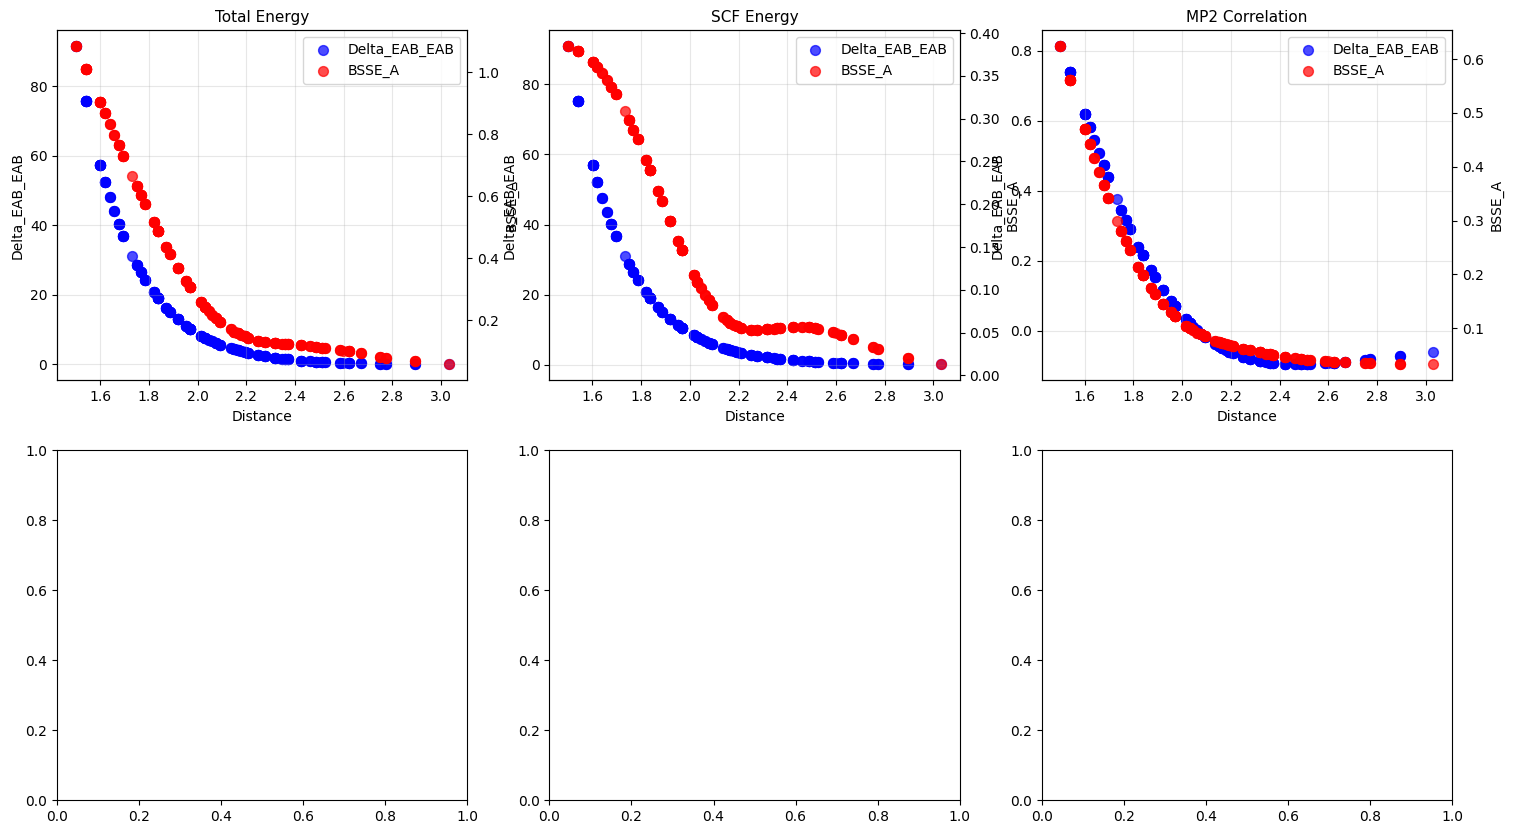

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
df = bsse_data_nwchem_kcal

# Define the energy types and their corresponding columns
energy_types = [
    "Total Energy",
    "SCF Energy",
    "MP2 Correlation",
    "CCSD Correlation",
    "(T) Correlation",
]

# Create separate subplots with dual y-axes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten for easier indexing

# Define colors
delta_color = "blue"
bsse_color = "red"

# Plot each energy type in separate subplot with dual y-axis
for i, label in enumerate(energy_types):
    delta_col = [
        col
        for col in df.columns
        if label.title() in col.replace("_", " ").title() and "Delta" in col
    ][0]
    bsse_col = [
        col
        for col in df.columns
        if label.title() in col.replace("_", " ").title() and "BSSE" in col
    ][0]
    if i < len(axes):
        ax1 = axes[i]

        # Remove any NaN values
        x = df.loc[mask, "distance"].values
        y_delta = df.loc[mask, delta_col].values
        y_bsse = df.loc[mask, bsse_col].values
        line1 = ax1.scatter(
            x, y_delta, color=delta_color, alpha=0.7, s=50, label="Delta_EAB_EAB"
        )
        ax1.set_xlabel("Distance", fontsize=10)
        ax1.set_ylabel("Delta_EAB_EAB", fontsize=10)

        # Create secondary y-axis (right)
        ax2 = ax1.twinx()
        line2 = ax2.scatter(
            x, y_bsse, color=bsse_color, alpha=0.7, s=50, label="BSSE_A"
        )
        ax2.set_ylabel("BSSE_A", fontsize=10)

        # Set title
        ax1.set_title(f"{label}", fontsize=11)

        # Add grid to primary axis
        ax1.grid(True, alpha=0.3)

        # Add legend
        lines = [line1, line2]
        labels = ["Delta_EAB_EAB", "BSSE_A"]
        ax1.legend(lines, labels, loc="upper right")

# Hide the last subplot if we have fewer than 6 energy types
if len(energy_types) < len(axes):
    axes[-1].axis("off")

# Adjust layout
plt.tight_layout()
fig.suptitle("Delta_EAB_EAB vs BSSE_A by Energy Component", fontsize=14, y=1.02)

# Show the plot
plt.show()

# Optional: Save the plot
# plt.savefig('delta_vs_bsse_dual_axis_plots.png', dpi=300, bbox_inches='tight')

In [ ]:
total_energies[(total_energies["distance"] > 3.4) & (total_energies["distance"] < 3.6)]

In [ ]:
fit_gauss = fit_gaussian(total_energies, 2)

In [ ]:
make_contour_plots_of_fitted_gaussian(total_energies, fit_gauss)

In [ ]:
predicted_v_actual_plot(total_energies, fit_gauss)

In [ ]:
make_error_contour_plots(total_energies, fit_gauss)

NameError: name 'bsse_data_nwchem_kcal' is not defined

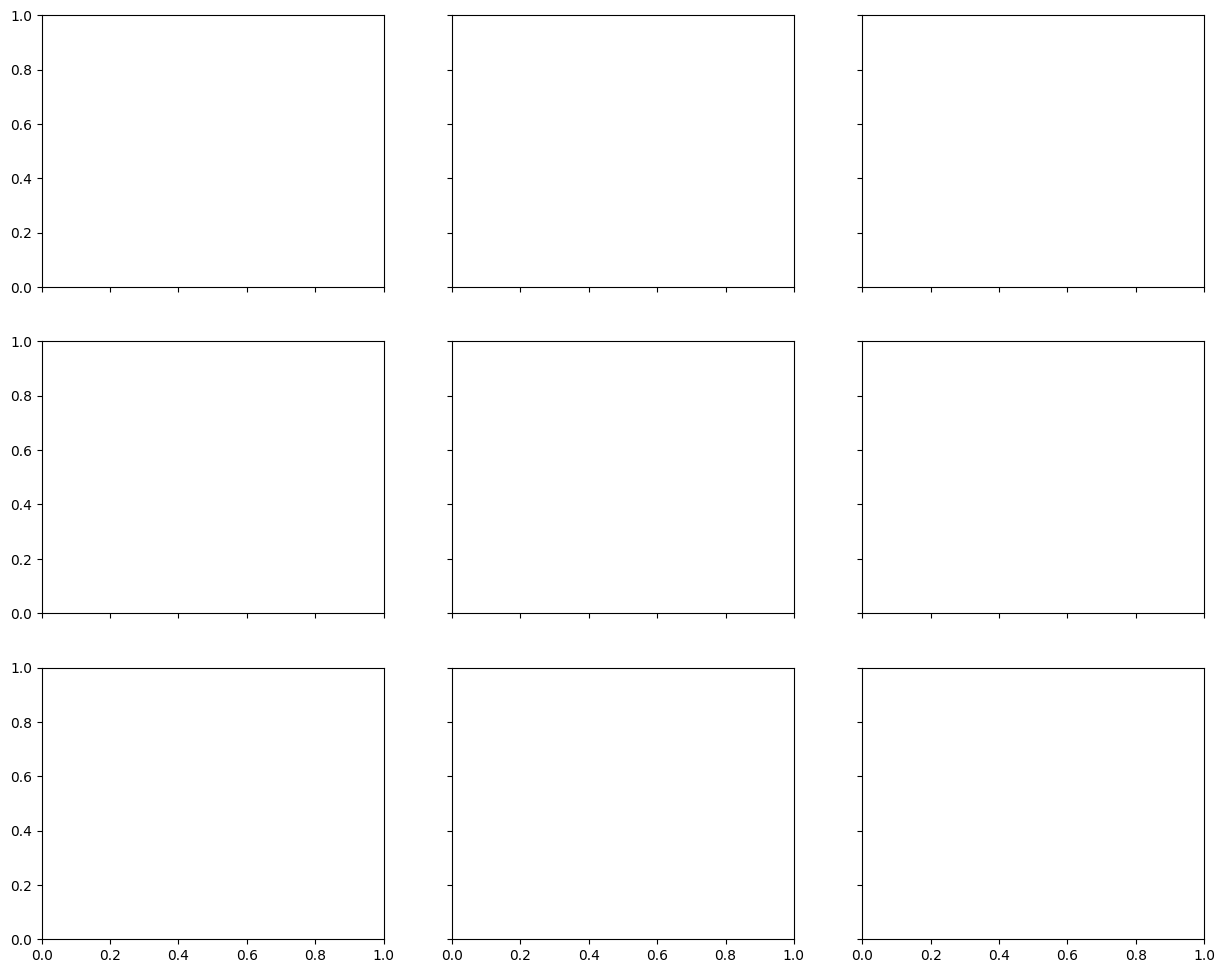

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# Define x and y grid values
x_vals = np.arange(0.5, 2, 0.5)
y_vals = np.arange(0.5, 2, 0.5)

nrows = len(y_vals)
ncols = len(x_vals)

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

cols = [
    "SCF_energy_BSSE_A",
    "MP2_correlation_energy_BSSE_A",
    "(T)_correlation_energy_BSSE_A",
    "CCSD corr.energy_BSSE_A",
]

legend_handles, legend_labels = None, None

for i, fixed_y in enumerate(y_vals):
    for j, fixed_x in enumerate(x_vals):
        ax = axes[i, j]
        fixed_x_df = bsse_data_nwchem_kcal[bsse_data_nwchem_kcal["x"] == fixed_x]
        fixed_y_df = fixed_x_df[fixed_x_df["y"] == fixed_y]
        if fixed_y_df.empty or not all(col in fixed_y_df.columns for col in cols):
            ax.axis("off")
            continue

        fixed_y_df = fixed_y_df.set_index("z")
        fixed_y_df[cols].plot(kind="bar", ax=ax, stacked=True, legend=False)
        ax.set_title(f"x={fixed_x}, y={fixed_y}")
        ax.set_xlabel("z")
        ax.set_ylabel("Energy")

        # Capture legend from the first valid plot
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

# Add global legend if we found any handles
if legend_handles:
    fig.legend(
        legend_handles, legend_labels, title="Energy Terms", loc="upper center", ncol=4
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

NameError: name 'bsse_data_nwchem_kcal' is not defined

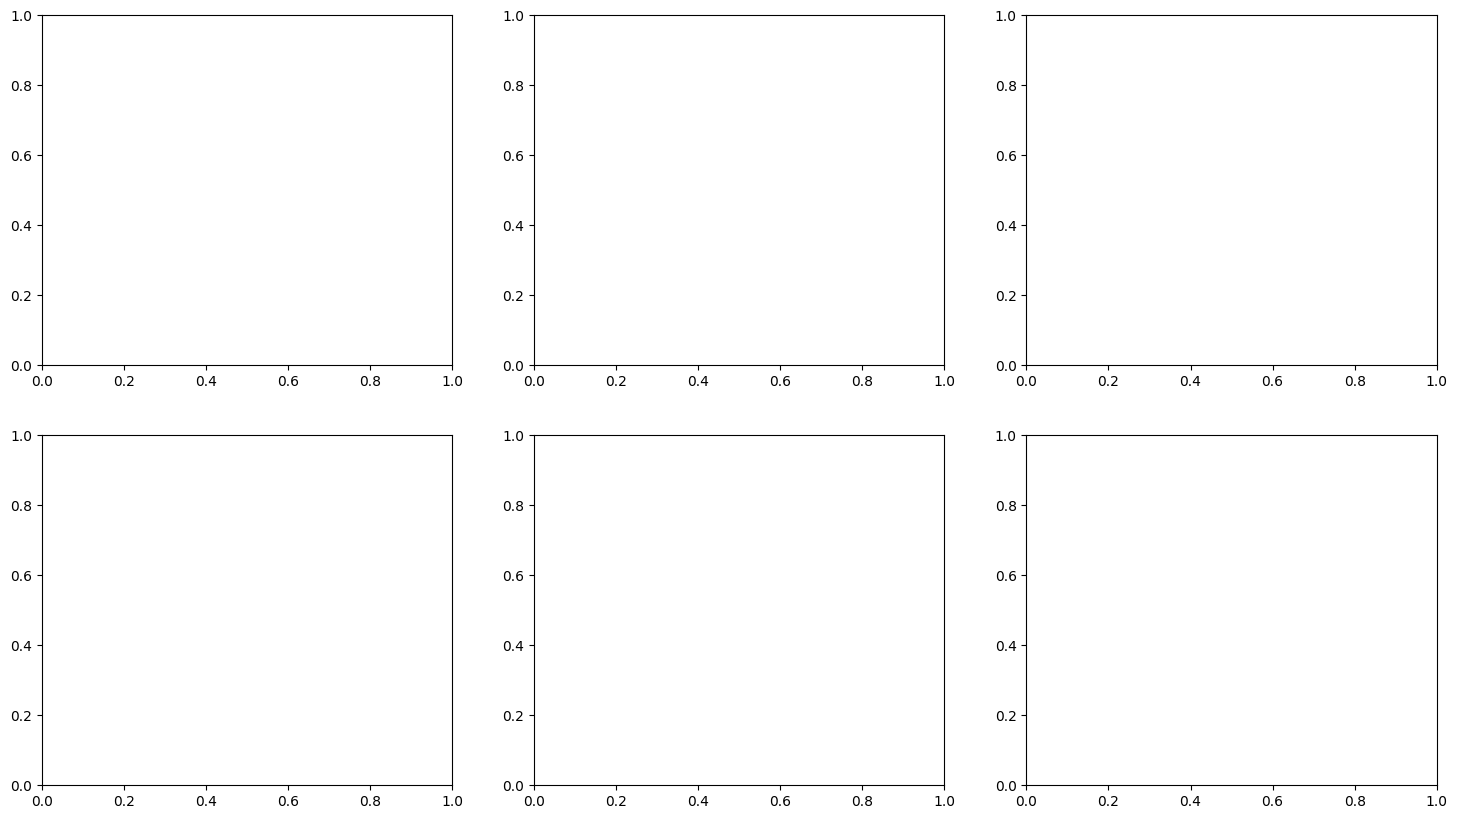

In [1]:
import numpy as np
import matplotlib.pyplot as plt

energy_types = [
    "Total_energy",
    "SCF_energy",
    "MP2_correlation_energy",
    "(T)_correlation_energy",
    "CCSD corr.energy",
]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, energy_type in enumerate(energy_types):
    ax = axes[i]
    x = abs(bsse_data_nwchem_kcal[f"{energy_type}_Delta_E_AB_AB"])
    y = abs(bsse_data_nwchem_kcal[f"{energy_type}_BSSE_A"])

    # Scatter
    ax.scatter(x, y)

    # Regression line
    slope, intercept = np.polyfit(x, y, 1)
    ax.plot(x, slope * x + intercept, color="red", label="Linear regression")
    ax.set_title(f"{energy_type}", fontsize=14)
    ax.set_xlabel(r"$\Delta E_{\mathrm{AB,AB}}$ " + f"kcal/mol")
    ax.set_ylabel(r"$\mathrm{{BSSE}}_A$ " + f"kcal/mol")
    # ax.legend()

# Hide unused subplot
if len(energy_types) < len(axes):
    for j in range(len(energy_types), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

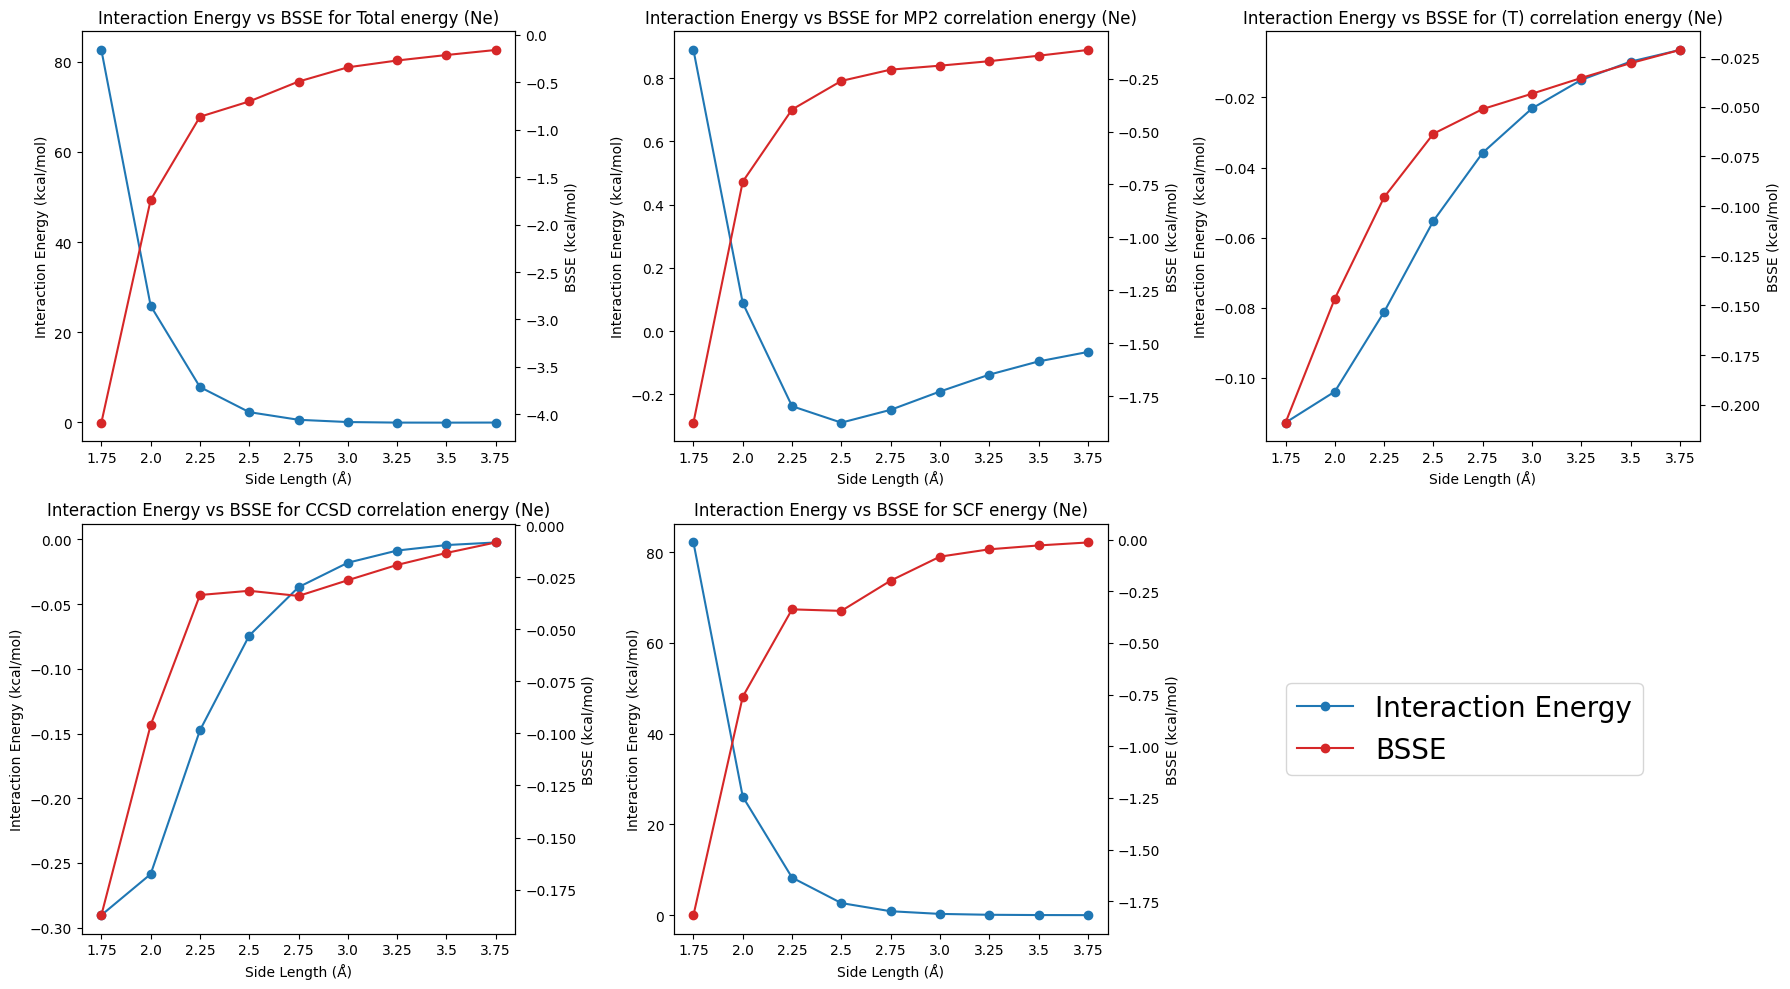

In [11]:
import json
from bsse_calculator.plotting_helpers import *
energies = json.loads(open("Ne_trimer_energies.json", "r").read())
energy_dfs = create_df(energies)
energy_dfs = {
    k: create_BSSEs_and_interaction_energies(df) for k, df in energy_dfs.items()
  }
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    formated_title = k.replace("_", " ")
    lines, labels = plot_dual_axis(
        df["Total Interaction Energy (BSSE free)"],
        df["Total BSSE"],
        df["side_length"],
        ax1=ax,
        title=f"Interaction Energy vs BSSE for {formated_title} (Ne)",
        x_label="Side Length (Å)",
        y1_label="Interaction Energy (kcal/mol)",
        y2_label="BSSE (kcal/mol)",
        label1="Interaction Energy",
        label2="BSSE",
    )
plt.tight_layout()
ax.legend(lines, labels, prop={'size': 20}, loc='center left', bbox_to_anchor=(1.380, 0.5))
fig.delaxes(axes[-1])
